FinSight Professional EDA

Import Libraries

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Load Cleaned Dataset

In [67]:
DATA_PATH = Path("../data/processed/transactions_cleaned.parquet")

df = pd.read_parquet(DATA_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,"9,839.64",C1231006815,"170,136.00","160,296.36",M1979787155,0.00,0.00,0,0
1,1,PAYMENT,"1,864.28",C1666544295,"21,249.00","19,384.72",M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,"21,182.00",0.00,1,0
4,1,PAYMENT,"11,668.14",C2048537720,"41,554.00","29,885.86",M1230701703,0.00,0.00,0,0


In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            int32   
 1   type            category
 2   amount          float32 
 3   nameOrig        str     
 4   oldbalanceOrg   float32 
 5   newbalanceOrig  float32 
 6   nameDest        str     
 7   oldbalanceDest  float32 
 8   newbalanceDest  float32 
 9   isFraud         int8    
 10  isFlaggedFraud  int8    
dtypes: category(1), float32(5), int32(1), int8(2), str(2)
memory usage: 388.1 MB


Dataset Overview

In [69]:
df.describe(include="all")

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,"6,362,620.00",6362620,"6,362,620.00",6362620,"6,362,620.00","6,362,620.00",6362620,"6,362,620.00","6,362,620.00","6,362,620.00","6,362,620.00"
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C2098525306,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,243.40,NaN,"179,861.89",NaN,"833,883.12","855,113.62",NaN,"1,100,701.75","1,224,996.38",0.00,0.00
std,142.33,NaN,"603,858.25",NaN,"2,888,242.75","2,924,048.50",NaN,"3,399,180.25","3,674,129.00",0.04,0.00
min,1.00,NaN,0.00,NaN,0.00,0.00,NaN,0.00,0.00,0.00,0.00
25%,156.00,NaN,"13,389.57",NaN,0.00,0.00,NaN,0.00,0.00,0.00,0.00
50%,239.00,NaN,"74,871.94",NaN,"14,208.00",0.00,NaN,"132,705.66","214,661.45",0.00,0.00
75%,335.00,NaN,"208,721.48",NaN,"107,315.18","144,258.41",NaN,"943,036.69","1,111,909.22",0.00,0.00


In [70]:
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Transaction Volume Analysis

In [71]:
transaction_counts = (
    df["type"]
    .value_counts()
    .rename_axis("transaction_type")
    .reset_index(name="transaction_count")
)

transaction_counts

,transaction_type,transaction_count
0,CASH_OUT,2237500
1,PAYMENT,2151495
2,CASH_IN,1399284
3,TRANSFER,532909
4,DEBIT,41432


In [72]:
transaction_counts["percentage"] = (
    transaction_counts["transaction_count"]
    / transaction_counts["transaction_count"].sum()
    * 100
)

transaction_counts

,transaction_type,transaction_count,percentage
0,CASH_OUT,2237500,35.17
1,PAYMENT,2151495,33.81
2,CASH_IN,1399284,21.99
3,TRANSFER,532909,8.38
4,DEBIT,41432,0.65


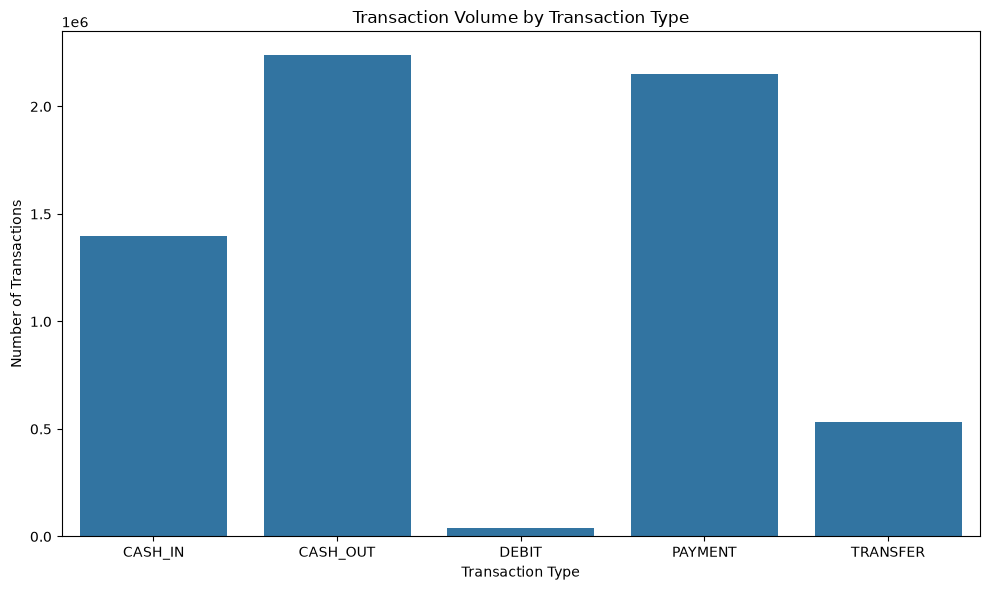

In [73]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=transaction_counts,
    x="transaction_type",
    y="transaction_count"
)

plt.title("Transaction Volume by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [74]:
transaction_counts.sort_values(
    "transaction_count",
    ascending=False
)

,transaction_type,transaction_count,percentage
0,CASH_OUT,2237500,35.17
1,PAYMENT,2151495,33.81
2,CASH_IN,1399284,21.99
3,TRANSFER,532909,8.38
4,DEBIT,41432,0.65


Transaction Value Analysis

In [75]:
transaction_value = (
    df.groupby("type", observed=True)["amount"]
    .agg(
        transaction_count="count",
        total_amount="sum",
        average_amount="mean",
        median_amount="median"
    )
    .sort_values("total_amount", ascending=False)
)

transaction_value

,transaction_count,total_amount,average_amount,median_amount
type,,,,
TRANSFER,532909,"485,291,982,848.00","910,647.00","486,308.38"
CASH_OUT,2237500,"394,412,982,272.00","176,273.95","147,072.19"
CASH_IN,1399284,"236,367,396,864.00","168,920.25","143,427.71"
PAYMENT,2151495,"28,093,370,368.00","13,057.60","9,482.19"
DEBIT,41432,"227,199,216.00","5,483.67","3,048.99"


In [76]:
transaction_value["value_percentage"] = (
    transaction_value["total_amount"]
    / transaction_value["total_amount"].sum()
    * 100
)

transaction_value

,transaction_count,total_amount,average_amount,median_amount,value_percentage
type,,,,,
TRANSFER,532909,"485,291,982,848.00","910,647.00","486,308.38",42.41
CASH_OUT,2237500,"394,412,982,272.00","176,273.95","147,072.19",34.46
CASH_IN,1399284,"236,367,396,864.00","168,920.25","143,427.71",20.65
PAYMENT,2151495,"28,093,370,368.00","13,057.60","9,482.19",2.45
DEBIT,41432,"227,199,216.00","5,483.67","3,048.99",0.02


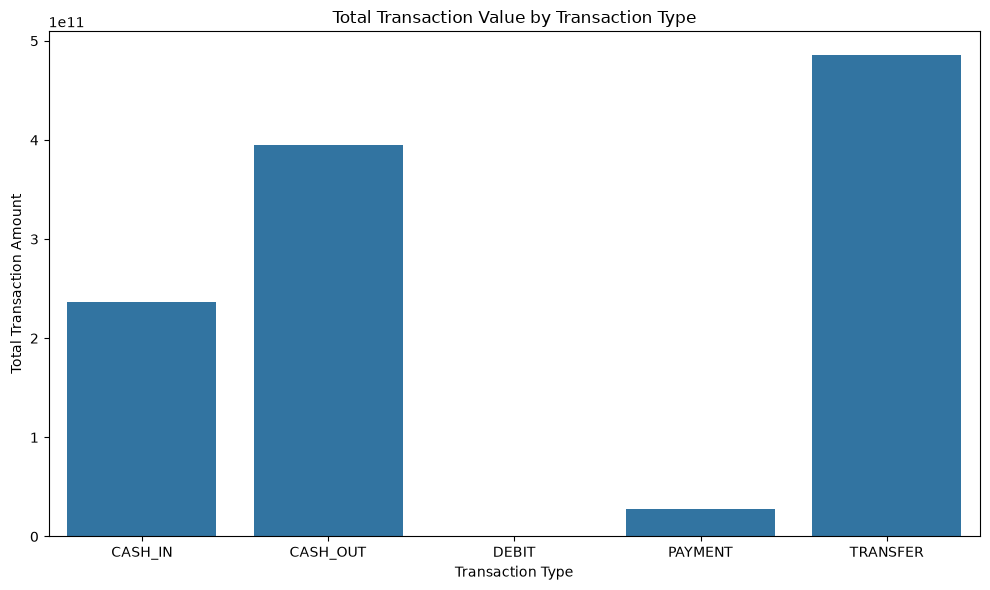

In [77]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=transaction_value.reset_index(),
    x="type",
    y="total_amount"
)

plt.title("Total Transaction Value by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Total Transaction Amount")
plt.tight_layout()
plt.show()

Volume vs Value

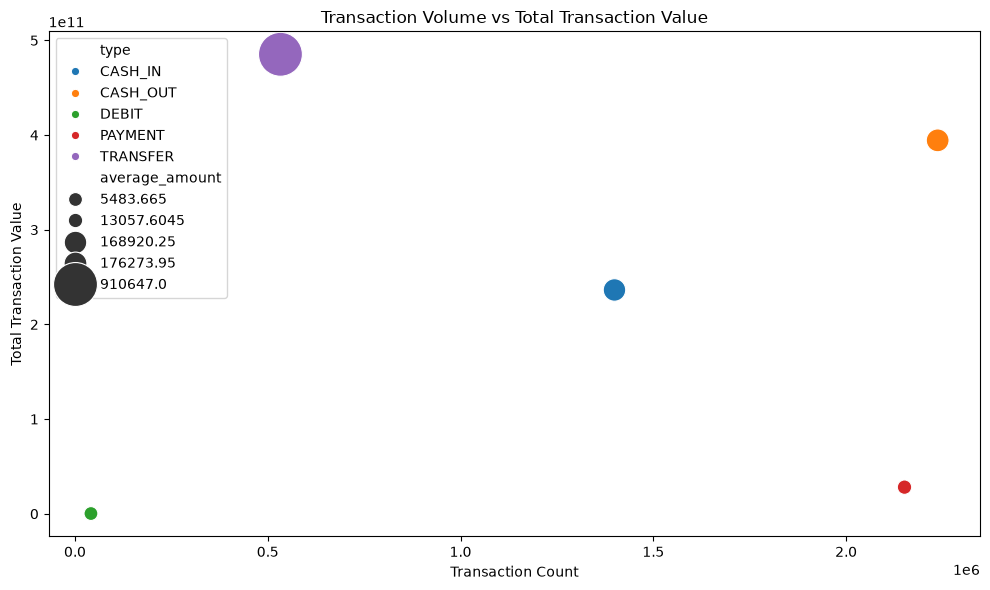

In [78]:
volume_value = transaction_value.reset_index()

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=volume_value,
    x="transaction_count",
    y="total_amount",
    size="average_amount",
    hue="type",
    sizes=(100, 1000)
)

plt.title("Transaction Volume vs Total Transaction Value")
plt.xlabel("Transaction Count")
plt.ylabel("Total Transaction Value")

plt.tight_layout()
plt.show()

In [79]:
transaction_counts



,transaction_type,transaction_count,percentage
0,CASH_OUT,2237500,35.17
1,PAYMENT,2151495,33.81
2,CASH_IN,1399284,21.99
3,TRANSFER,532909,8.38
4,DEBIT,41432,0.65


In [80]:
transaction_value

,transaction_count,total_amount,average_amount,median_amount,value_percentage
type,,,,,
TRANSFER,532909,"485,291,982,848.00","910,647.00","486,308.38",42.41
CASH_OUT,2237500,"394,412,982,272.00","176,273.95","147,072.19",34.46
CASH_IN,1399284,"236,367,396,864.00","168,920.25","143,427.71",20.65
PAYMENT,2151495,"28,093,370,368.00","13,057.60","9,482.19",2.45
DEBIT,41432,"227,199,216.00","5,483.67","3,048.99",0.02


Transaction Amount Distribution

In [81]:
df["amount"].describe()

count    6,362,620.00
mean       179,861.89
std        603,858.25
min              0.00
25%         13,389.57
50%         74,871.94
75%        208,721.48
max     92,445,520.00
Name: amount, dtype: float64

In [82]:
df["amount"].quantile([0.50, 0.75, 0.90, 0.95, 0.99, 0.999])

0.50      74,871.94
0.75     208,721.48
0.90     365,423.30
0.95     518,634.19
0.99   1,615,979.50
1.00   8,956,797.63
Name: amount, dtype: float64

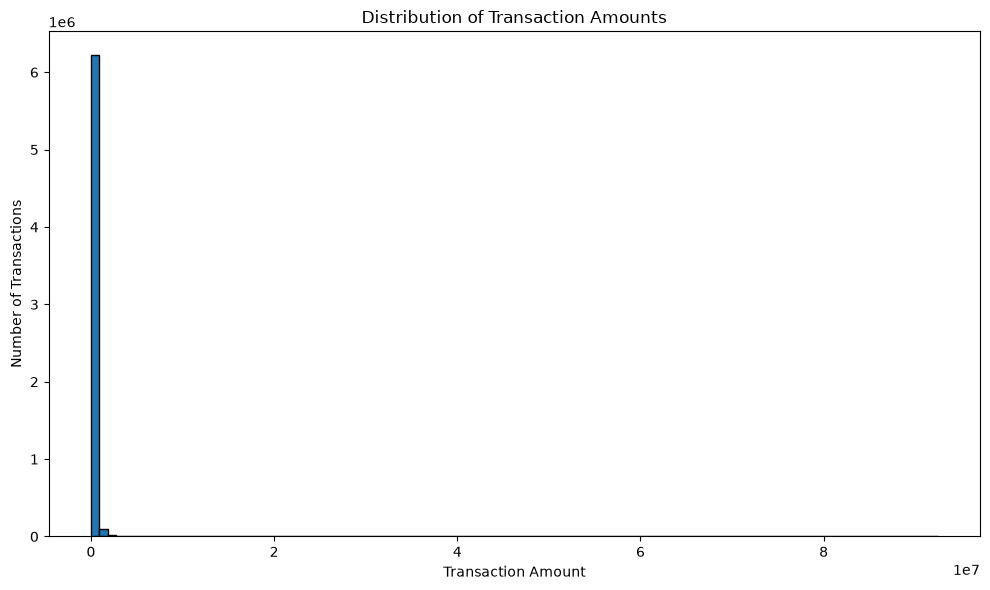

In [83]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["amount"],
    bins=100,
    edgecolor="black"
)

plt.title("Distribution of Transaction Amounts")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

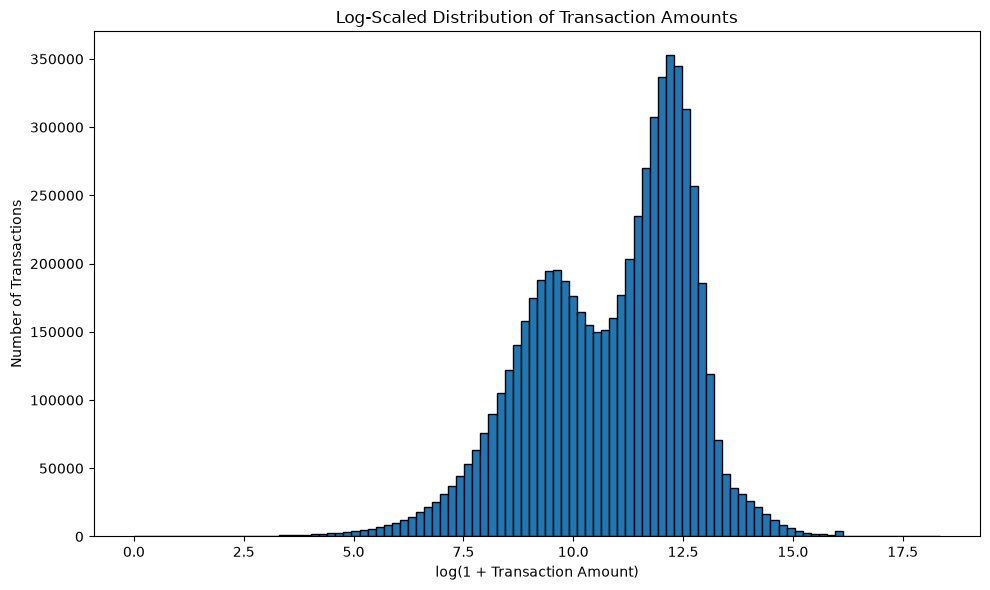

In [84]:
plt.figure(figsize=(10, 6))

plt.hist(
    np.log1p(df["amount"]),
    bins=100,
    edgecolor="black"
)

plt.title("Log-Scaled Distribution of Transaction Amounts")
plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Outlier investigation

In [85]:
amount_quantiles = df["amount"].quantile(
    [0.50, 0.90, 0.95, 0.99, 0.999]
)

amount_quantiles

0.50      74,871.94
0.90     365,423.30
0.95     518,634.19
0.99   1,615,979.50
1.00   8,956,797.63
Name: amount, dtype: float64

In [86]:
top_transactions = (
    df.nlargest(20, "amount")
    [
        [
            "step",
            "type",
            "amount",
            "nameOrig",
            "nameDest",
            "isFraud"
        ]
    ]
)

top_transactions

,step,type,amount,nameOrig,nameDest,isFraud
3686583,276,TRANSFER,"92,445,520.00",C1715283297,C439737079,0
4060598,300,TRANSFER,"73,823,488.00",C2127282686,C753026640,0
4146397,303,TRANSFER,"71,172,480.00",C2044643633,C84111522,0
3946920,286,TRANSFER,"69,886,728.00",C1425667947,C167875008,0
3911956,284,TRANSFER,"69,337,320.00",C1584456031,C1472140329,0
3937152,286,TRANSFER,"67,500,760.00",C811810230,C1757599079,0
4105338,302,TRANSFER,"66,761,272.00",C420748282,C1073241084,0
3892529,284,TRANSFER,"64,234,448.00",C1139847449,C65111466,0
3991638,298,TRANSFER,"63,847,992.00",C300140823,C514940761,0
4143801,303,TRANSFER,"63,294,840.00",C372535854,C1871605747,0


Time-Based Transaction Analysis

In [87]:
transactions_by_step = (
    df.groupby("step")
    .size()
    .reset_index(name="transaction_count")
)

transactions_by_step.head()

,step,transaction_count
0,1,2708
1,2,1014
2,3,552
3,4,565
4,5,665


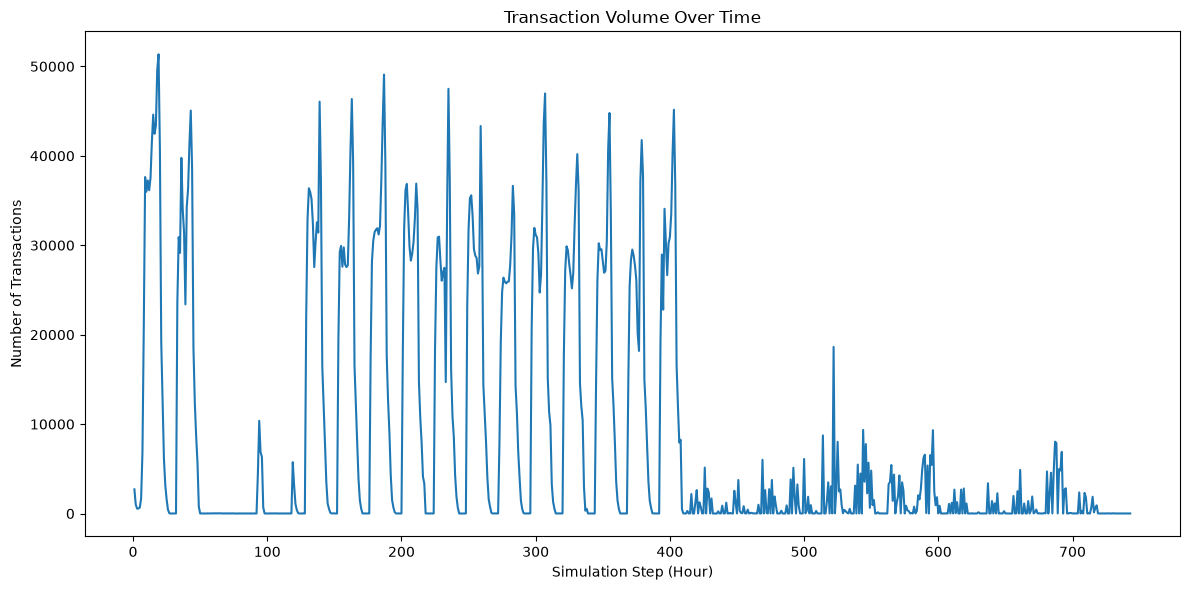

In [88]:
plt.figure(figsize=(12, 6))

plt.plot(
    transactions_by_step["step"],
    transactions_by_step["transaction_count"]
)

plt.title("Transaction Volume Over Time")
plt.xlabel("Simulation Step (Hour)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Transactions per hour

In [89]:
value_by_step = (
    df.groupby("step")["amount"]
    .sum()
    .reset_index(name="total_amount")
)

value_by_step.head()

,step,total_amount
0,1,"285,429,184.00"
1,2,"85,921,608.00"
2,3,"43,293,884.00"
3,4,"72,910,032.00"
4,5,"45,548,088.00"


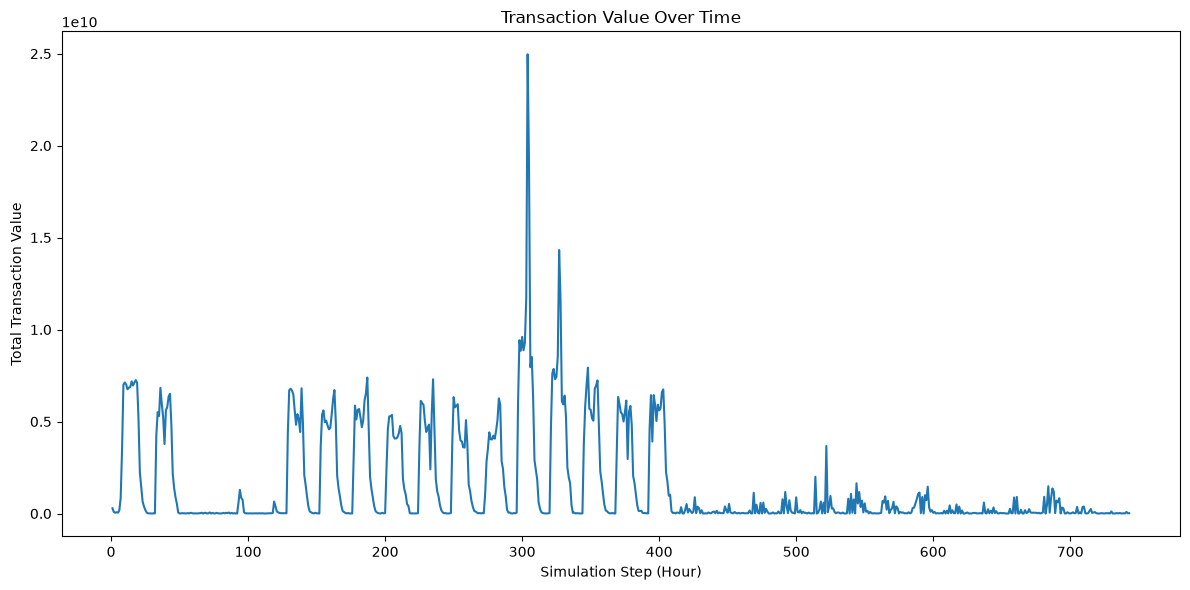

In [90]:
plt.figure(figsize=(12, 6))

plt.plot(
    value_by_step["step"],
    value_by_step["total_amount"]
)

plt.title("Transaction Value Over Time")
plt.xlabel("Simulation Step (Hour)")
plt.ylabel("Total Transaction Value")

plt.tight_layout()
plt.show()

Transaction value over time

In [91]:
value_by_step = (
    df.groupby("step")["amount"]
    .sum()
    .reset_index(name="total_amount")
)

value_by_step.head()

,step,total_amount
0,1,"285,429,184.00"
1,2,"85,921,608.00"
2,3,"43,293,884.00"
3,4,"72,910,032.00"
4,5,"45,548,088.00"


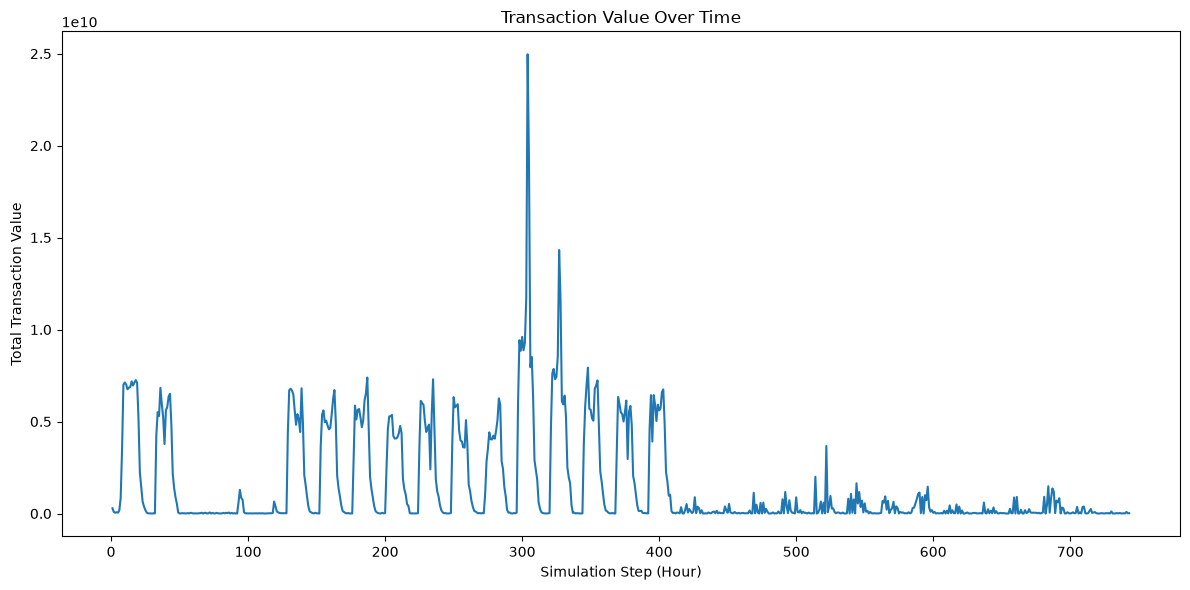

In [92]:
plt.figure(figsize=(12, 6))

plt.plot(
    value_by_step["step"],
    value_by_step["total_amount"]
)

plt.title("Transaction Value Over Time")
plt.xlabel("Simulation Step (Hour)")
plt.ylabel("Total Transaction Value")

plt.tight_layout()
plt.show()

Fraud over time

In [93]:
fraud_by_step = (
    df.groupby("step")["isFraud"]
    .agg(
        transactions="count",
        fraud_cases="sum"
    )
    .reset_index()
)

fraud_by_step["fraud_rate"] = (
    fraud_by_step["fraud_cases"]
    / fraud_by_step["transactions"]
    * 100
)

fraud_by_step.head()

,step,transactions,fraud_cases,fraud_rate
0,1,2708,16,0.59
1,2,1014,8,0.79
2,3,552,4,0.72
3,4,565,10,1.77
4,5,665,6,0.90


highest fraud-rate periods

In [94]:
fraud_by_step.sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate
726,727,12,12,100.00
742,743,8,8,100.00
741,742,14,14,100.00
409,410,20,20,100.00
410,411,16,16,100.00
411,412,8,8,100.00
413,414,16,16,100.00
414,415,16,16,100.00
416,417,6,6,100.00
417,418,6,6,100.00


highest fraud-count periods

In [95]:
fraud_by_step.sort_values(
    "fraud_cases",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate
211,212,34047,40,0.12
522,523,30,30,100.00
386,387,28,28,100.00
500,501,28,28,100.00
729,730,28,28,100.00
424,425,28,28,100.00
248,249,23209,28,0.12
397,398,26656,26,0.10
159,160,27765,26,0.09
405,406,12023,24,0.20


In [96]:
transactions_by_step

,step,transaction_count
0,1,2708
1,2,1014
2,3,552
3,4,565
4,5,665
...,...,...
738,739,10
739,740,6
740,741,22
741,742,14


In [97]:
value_by_step

,step,total_amount
0,1,"285,429,184.00"
1,2,"85,921,608.00"
2,3,"43,293,884.00"
3,4,"72,910,032.00"
4,5,"45,548,088.00"
...,...,...
738,739,"16,587,831.00"
739,740,"7,632,963.50"
740,741,"87,828,992.00"
741,742,"14,323,736.00"


In [98]:
fraud_by_step.sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate
726,727,12,12,100.00
742,743,8,8,100.00
741,742,14,14,100.00
409,410,20,20,100.00
410,411,16,16,100.00
411,412,8,8,100.00
413,414,16,16,100.00
414,415,16,16,100.00
416,417,6,6,100.00
417,418,6,6,100.00


In [99]:
MIN_TRANSACTIONS = 1000

meaningful_fraud_periods = fraud_by_step[
    fraud_by_step["transactions"] >= MIN_TRANSACTIONS
].copy()

meaningful_fraud_periods = meaningful_fraud_periods.sort_values(
    "fraud_rate",
    ascending=False
)

meaningful_fraud_periods.head(20)

,step,transactions,fraud_cases,fraud_rate
663,664,1125,20,1.78
620,621,1121,18,1.61
607,608,1082,16,1.48
5,6,1660,22,1.33
120,121,1074,14,1.30
144,145,1117,14,1.25
613,614,1278,16,1.25
568,569,1182,14,1.18
24,25,1598,18,1.13
639,640,1398,14,1.00


In [100]:
meaningful_fraud_periods.sort_values(
    "fraud_cases",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate
211,212,34047,40,0.12
248,249,23209,28,0.12
397,398,26656,26,0.10
159,160,27765,26,0.09
405,406,12023,24,0.20
693,694,2664,24,0.90
21,22,12635,23,0.18
33,34,30904,22,0.07
5,6,1660,22,1.33
261,262,11125,22,0.20


compare fraud vs legitimate transactions

In [101]:
overall_fraud_rate = df["isFraud"].mean() * 100

print(f"Overall fraud rate: {overall_fraud_rate:.4f}%")

Overall fraud rate: 0.1291%


In [102]:
fraud_by_step["fraud_rate_vs_baseline"] = (
    fraud_by_step["fraud_rate"] / overall_fraud_rate
)

fraud_by_step.sort_values(
    "fraud_rate_vs_baseline",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate,fraud_rate_vs_baseline
726,727,12,12,100.00,774.70
742,743,8,8,100.00,774.70
741,742,14,14,100.00,774.70
409,410,20,20,100.00,774.70
410,411,16,16,100.00,774.70
411,412,8,8,100.00,774.70
413,414,16,16,100.00,774.70
414,415,16,16,100.00,774.70
416,417,6,6,100.00,774.70
417,418,6,6,100.00,774.70


In [103]:
meaningful_fraud_periods = fraud_by_step[
    fraud_by_step["transactions"] >= 1000
].copy()

meaningful_fraud_periods["fraud_rate_vs_baseline"] = (
    meaningful_fraud_periods["fraud_rate"]
    / overall_fraud_rate
)

meaningful_fraud_periods.sort_values(
    "fraud_rate_vs_baseline",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate,fraud_rate_vs_baseline
663,664,1125,20,1.78,13.77
620,621,1121,18,1.61,12.44
607,608,1082,16,1.48,11.46
5,6,1660,22,1.33,10.27
120,121,1074,14,1.30,10.10
144,145,1117,14,1.25,9.71
613,614,1278,16,1.25,9.70
568,569,1182,14,1.18,9.18
24,25,1598,18,1.13,8.73
639,640,1398,14,1.00,7.76


In [104]:
meaningful_fraud_periods.head(20)



,step,transactions,fraud_cases,fraud_rate,fraud_rate_vs_baseline
0,1,2708,16,0.59,4.58
1,2,1014,8,0.79,6.11
5,6,1660,22,1.33,10.27
6,7,6837,12,0.18,1.36
7,8,21097,12,0.06,0.44
8,9,37628,19,0.05,0.39
9,10,35991,11,0.03,0.24
10,11,37241,7,0.02,0.15
11,12,36153,14,0.04,0.30
12,13,37515,14,0.04,0.29


In [105]:
meaningful_fraud_periods.sort_values(
    "fraud_cases",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate,fraud_rate_vs_baseline
211,212,34047,40,0.12,0.91
248,249,23209,28,0.12,0.93
397,398,26656,26,0.10,0.76
159,160,27765,26,0.09,0.73
405,406,12023,24,0.20,1.55
693,694,2664,24,0.90,6.98
21,22,12635,23,0.18,1.41
249,250,31854,22,0.07,0.54
261,262,11125,22,0.20,1.53
278,279,25925,22,0.08,0.66


In [106]:
fraud_by_step.sort_values(
    "fraud_rate_vs_baseline",
    ascending=False
).head(20)

,step,transactions,fraud_cases,fraud_rate,fraud_rate_vs_baseline
726,727,12,12,100.00,774.70
742,743,8,8,100.00,774.70
741,742,14,14,100.00,774.70
409,410,20,20,100.00,774.70
410,411,16,16,100.00,774.70
411,412,8,8,100.00,774.70
413,414,16,16,100.00,774.70
414,415,16,16,100.00,774.70
416,417,6,6,100.00,774.70
417,418,6,6,100.00,774.70


Origin Account Behavior

Account transaction frequency

In [107]:
origin_activity = (
    df.groupby("nameOrig")
    .agg(
        transaction_count=("amount", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean"),
        fraud_cases=("isFraud", "sum")
    )
    .sort_values("transaction_count", ascending=False)
)

origin_activity.head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameOrig,,,,
C1832548028,3,"313,665.84","104,555.28",0
C1530544995,3,"490,535.06","163,511.69",0
C1065307291,3,"113,479.28","37,826.43",0
C1902386530,3,"763,712.81","254,570.94",0
C1784010646,3,"436,700.25","145,566.75",0
C1462946854,3,"166,791.44","55,597.14",0
C1677795071,3,"244,735.38","81,578.46",0
C1976208114,3,"511,130.38","170,376.80",0
C1999539787,3,"290,555.00","96,851.66",0


Most active accounts

In [108]:
origin_activity.head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameOrig,,,,
C1832548028,3,"313,665.84","104,555.28",0
C1530544995,3,"490,535.06","163,511.69",0
C1065307291,3,"113,479.28","37,826.43",0
C1902386530,3,"763,712.81","254,570.94",0
C1784010646,3,"436,700.25","145,566.75",0
C1462946854,3,"166,791.44","55,597.14",0
C1677795071,3,"244,735.38","81,578.46",0
C1976208114,3,"511,130.38","170,376.80",0
C1999539787,3,"290,555.00","96,851.66",0


Highest-value origin accounts


In [109]:
origin_activity.sort_values(
    "total_amount",
    ascending=False
).head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameOrig,,,,
C1715283297,1,"92,445,520.00","92,445,520.00",0
C2127282686,1,"73,823,488.00","73,823,488.00",0
C2044643633,1,"71,172,480.00","71,172,480.00",0
C1425667947,1,"69,886,728.00","69,886,728.00",0
C1584456031,1,"69,337,320.00","69,337,320.00",0
C811810230,1,"67,500,760.00","67,500,760.00",0
C420748282,1,"66,761,272.00","66,761,272.00",0
C1139847449,1,"64,234,448.00","64,234,448.00",0
C300140823,1,"63,847,992.00","63,847,992.00",0


Accounts associated with fraud

In [110]:
fraud_origin_accounts = origin_activity[
    origin_activity["fraud_cases"] > 0
].sort_values(
    "fraud_cases",
    ascending=False
)

fraud_origin_accounts.head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameOrig,,,,
C1899367925,2,"35,435.68","17,717.84",1
C33272921,1,"445,705.75","445,705.75",1
C355768552,1,"6,417,789.00","6,417,789.00",1
C355611635,1,"370,382.38","370,382.38",1
C355594712,1,"1,858,515.62","1,858,515.62",1
C355424107,1,"1,679,154.50","1,679,154.50",1
C355341825,1,"1,380,940.75","1,380,940.75",1
C355084897,1,"55,247.48","55,247.48",1
C354542931,1,"339,152.25","339,152.25",1


fraud rate at account level

In [111]:
origin_activity["fraud_rate"] = (
    origin_activity["fraud_cases"]
    / origin_activity["transaction_count"]
    * 100
)

In [112]:
origin_activity[
    origin_activity["transaction_count"] >= 5
].sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,transaction_count,total_amount,average_amount,fraud_cases,fraud_rate
nameOrig,,,,,


In [113]:
origin_activity.head(20)

,transaction_count,total_amount,average_amount,fraud_cases,fraud_rate
nameOrig,,,,,
C1832548028,3,"313,665.84","104,555.28",0,0.00
C1530544995,3,"490,535.06","163,511.69",0,0.00
C1065307291,3,"113,479.28","37,826.43",0,0.00
C1902386530,3,"763,712.81","254,570.94",0,0.00
C1784010646,3,"436,700.25","145,566.75",0,0.00
C1462946854,3,"166,791.44","55,597.14",0,0.00
C1677795071,3,"244,735.38","81,578.46",0,0.00
C1976208114,3,"511,130.38","170,376.80",0,0.00
C1999539787,3,"290,555.00","96,851.66",0,0.00


In [114]:
origin_activity.sort_values(
    "total_amount",
    ascending=False
).head(20)

,transaction_count,total_amount,average_amount,fraud_cases,fraud_rate
nameOrig,,,,,
C1715283297,1,"92,445,520.00","92,445,520.00",0,0.00
C2127282686,1,"73,823,488.00","73,823,488.00",0,0.00
C2044643633,1,"71,172,480.00","71,172,480.00",0,0.00
C1425667947,1,"69,886,728.00","69,886,728.00",0,0.00
C1584456031,1,"69,337,320.00","69,337,320.00",0,0.00
C811810230,1,"67,500,760.00","67,500,760.00",0,0.00
C420748282,1,"66,761,272.00","66,761,272.00",0,0.00
C1139847449,1,"64,234,448.00","64,234,448.00",0,0.00
C300140823,1,"63,847,992.00","63,847,992.00",0,0.00


In [115]:
fraud_origin_accounts.head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameOrig,,,,
C1899367925,2,"35,435.68","17,717.84",1
C33272921,1,"445,705.75","445,705.75",1
C355768552,1,"6,417,789.00","6,417,789.00",1
C355611635,1,"370,382.38","370,382.38",1
C355594712,1,"1,858,515.62","1,858,515.62",1
C355424107,1,"1,679,154.50","1,679,154.50",1
C355341825,1,"1,380,940.75","1,380,940.75",1
C355084897,1,"55,247.48","55,247.48",1
C354542931,1,"339,152.25","339,152.25",1


In [116]:
origin_activity[
    origin_activity["transaction_count"] >= 5
].sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,transaction_count,total_amount,average_amount,fraud_cases,fraud_rate
nameOrig,,,,,


Destination Account Intelligence

Destination activity


In [117]:
destination_activity = (
    df.groupby("nameDest")
    .agg(
        transaction_count=("amount", "count"),
        total_amount=("amount", "sum"),
        average_amount=("amount", "mean"),
        fraud_cases=("isFraud", "sum")
    )
    .sort_values("transaction_count", ascending=False)
)

destination_activity.head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameDest,,,,
C1286084959,113,"77,428,944.00","685,211.88",0
C985934102,109,"42,422,888.00","389,200.81",0
C665576141,105,"88,749,384.00","845,232.25",0
C2083562754,102,"53,073,940.00","520,332.75",0
C248609774,101,"40,680,160.00","402,773.88",0
C1590550415,101,"43,206,100.00","427,783.16",0
C451111351,99,"37,453,032.00","378,313.47",0
C1789550256,99,"177,885,264.00","1,796,820.88",0
C1360767589,98,"35,121,288.00","358,380.50",0


Highest-value destinations

In [118]:
destination_activity.sort_values(
    "total_amount",
    ascending=False
).head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameDest,,,,
C439737079,18,"357,440,832.00","19,857,824.00",0
C707403537,17,"299,374,432.00","17,610,260.00",0
C167875008,28,"274,736,416.00","9,812,015.00",0
C20253152,20,"270,116,192.00","13,505,810.00",0
C172409641,57,"255,310,176.00","4,479,126.00",0
C268913927,35,"253,484,592.00","7,242,417.00",0
C936857833,46,"227,780,016.00","4,951,739.50",0
C65111466,22,"227,443,840.00","10,338,356.00",1
C744189981,26,"225,173,856.00","8,660,533.00",0


Fraud-associated destinations

In [119]:
fraud_destination_accounts = destination_activity[
    destination_activity["fraud_cases"] > 0
].sort_values(
    "fraud_cases",
    ascending=False
)

fraud_destination_accounts.head(20)

,transaction_count,total_amount,average_amount,fraud_cases
nameDest,,,,
C1827800010,3,"1,320,692.38","440,230.78",2
C1837027614,2,"951,189.88","475,594.94",2
C1193568854,37,"10,871,155.00","293,815.00",2
C1601170327,16,"6,549,520.00","409,345.00",2
C505532836,6,"855,971.44","142,661.91",2
C2020337583,41,"7,611,259.50","185,640.47",2
C200064275,33,"6,601,097.00","200,033.25",2
C385133759,18,"5,618,285.00","312,126.94",2
C410033330,48,"24,450,708.00","509,389.75",2


Destination fraud rate

In [120]:
destination_activity["fraud_rate"] = (
    destination_activity["fraud_cases"]
    / destination_activity["transaction_count"]
    * 100
)

In [121]:
destination_activity[
    destination_activity["transaction_count"] >= 5
].sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,transaction_count,total_amount,average_amount,fraud_cases,fraud_rate
nameDest,,,,,
C668046170,5,"10,965,897.00","2,193,179.50",2,40.00
C505532836,6,"855,971.44","142,661.91",2,33.33
C1185292292,6,"851,350.94","141,891.83",2,33.33
C1780714769,6,"1,251,668.00","208,611.33",2,33.33
C650699445,9,"3,207,842.25","356,426.91",2,22.22
C1259079602,9,"3,184,910.50","353,878.94",2,22.22
C1653587362,9,"2,240,901.00","248,989.00",2,22.22
C1984865103,5,"441,496.88","88,299.38",1,20.00
C583085719,5,"936,369.00","187,273.80",1,20.00


Transaction Type × Fraud

In [122]:
fraud_type_analysis = (
    df.groupby("type", observed=True)
    .agg(
        transactions=("isFraud", "count"),
        fraud_cases=("isFraud", "sum"),
        total_amount=("amount", "sum"),
        fraud_amount=("amount", lambda x: x[df.loc[x.index, "isFraud"] == 1].sum())
    )
)

fraud_type_analysis["fraud_rate"] = (
    fraud_type_analysis["fraud_cases"]
    / fraud_type_analysis["transactions"]
    * 100
)

fraud_type_analysis["fraud_value_share"] = (
    fraud_type_analysis["fraud_amount"]
    / fraud_type_analysis["total_amount"]
    * 100
)

fraud_type_analysis

,transactions,fraud_cases,total_amount,fraud_amount,fraud_rate,fraud_value_share
type,,,,,,
CASH_IN,1399284,0,"236,367,396,864.00",0.00,0.00,0.00
CASH_OUT,2237500,4116,"394,412,982,272.00","5,989,201,920.00",0.18,1.52
DEBIT,41432,0,"227,199,216.00",0.00,0.00,0.00
PAYMENT,2151495,0,"28,093,370,368.00",0.00,0.00,0.00
TRANSFER,532909,4097,"485,291,982,848.00","6,067,213,312.00",0.77,1.25


Fraud Amount Analysis

In [123]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,"6,354,407.00","178,197.05","596,237.00",0.01,"13,368.40","74,684.72","208,364.77","92,445,520.00"
1,"8,213.00","1,467,967.38","2,404,253.00",0.00,"127,091.33","441,423.44","1,517,771.50","10,000,000.00"


In [124]:
fraud_amount_summary = (
    df.groupby("isFraud")["amount"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        max="max"
    )
)

fraud_amount_summary

,count,mean,median,max
isFraud,,,,
0,6354407,"178,197.05","74,684.72","92,445,520.00"
1,8213,"1,467,967.25","441,423.44","10,000,000.00"


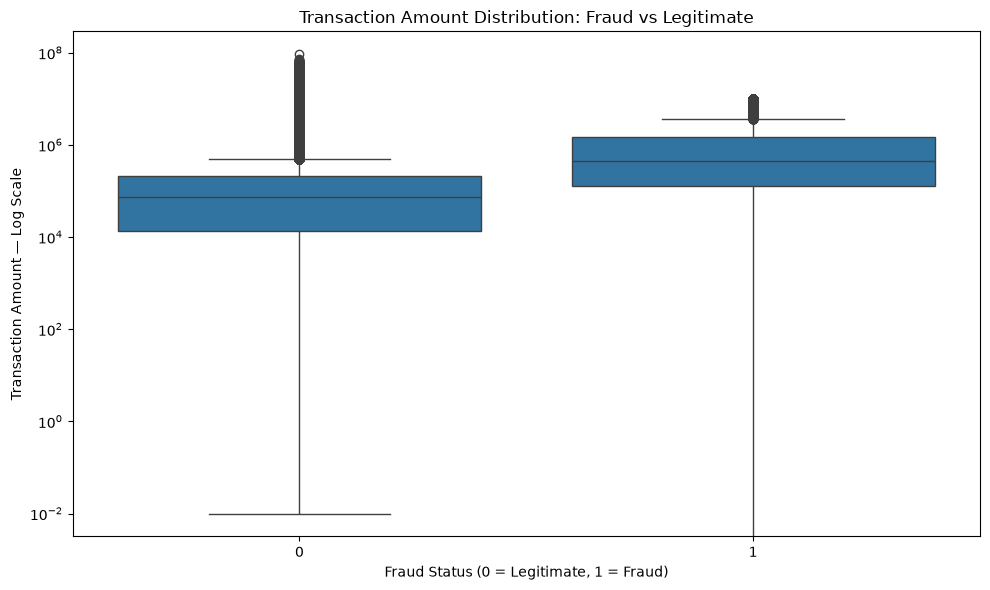

In [125]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="isFraud",
    y="amount"
)

plt.yscale("log")

plt.title("Transaction Amount Distribution: Fraud vs Legitimate")
plt.xlabel("Fraud Status (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount — Log Scale")

plt.tight_layout()
plt.show()

Fraud by Transaction Type

In [126]:
fraud_rates = (
    df.groupby("type", observed=True)["isFraud"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="fraud_rate")
)

fraud_rates

,type,fraud_rate
0,TRANSFER,0.77
1,CASH_OUT,0.18
2,CASH_IN,0.00
3,DEBIT,0.00
4,PAYMENT,0.00


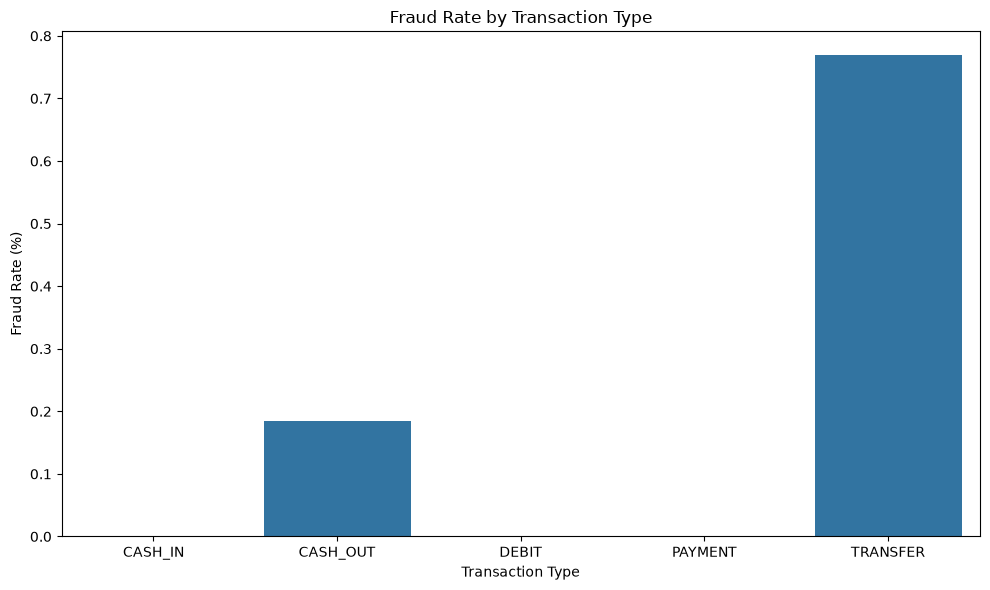

In [127]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=fraud_rates,
    x="type",
    y="fraud_rate"
)

plt.title("Fraud Rate by Transaction Type")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

Fraudulent Transaction Behavior

In [128]:
fraud_df = df[df["isFraud"] == 1].copy()

print(f"Fraud transactions: {len(fraud_df):,}")

Fraud transactions: 8,213


In [129]:
fraud_df["type"].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: count, dtype: int64

In [130]:
fraud_df.groupby("type", observed=True)["amount"].agg(
    ["count", "mean", "median", "min", "max", "sum"]
)

,count,mean,median,min,max,sum
type,,,,,,
CASH_OUT,4116,"1,455,102.62","435,516.91",0.00,"10,000,000.00","5,989,202,432.00"
TRANSFER,4097,"1,480,891.75","445,705.75",63.80,"10,000,000.00","6,067,213,312.00"


Existing Rule Performance

In [131]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df["isFraud"],
    df["isFlaggedFraud"]
)

cm

array([[6354407,       0],
       [   8197,      16]])

In [132]:
tn, fp, fn, tp = cm.ravel()

print(f"True Negatives : {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives : {tp:,}")

True Negatives : 6,354,407
False Positives: 0
False Negatives: 8,197
True Positives : 16


In [133]:
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0

print(f"Precision: {precision:.4%}")
print(f"Recall:    {recall:.4%}")

Precision: 100.0000%
Recall:    0.1948%
